In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

In [2]:
fund = pd.read_csv("E:/Project/data/processed/fund_master_clean.csv")
nav = pd.read_csv("E:/Project/data/processed/nav_history_clean.csv")
performance = pd.read_csv("E:/Project/data/processed/scheme_performance_clean.csv")
benchmark = pd.read_csv("E:/Project/data/processed/benchmark_indices_clean.csv")

In [3]:
print("Fund :", fund.shape)
print("NAV :", nav.shape)
print("Performance :", performance.shape)
print("Benchmark :", benchmark.shape)

Fund : (40, 15)
NAV : (46000, 3)
Performance : (40, 19)
Benchmark : (8050, 3)


In [4]:
nav["date"] = pd.to_datetime(nav["date"])

In [5]:
nav = nav.sort_values(
    by=["amfi_code", "date"]
)

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [6]:
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

nav.head(10)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


In [7]:
nav[["amfi_code", "date", "nav", "daily_return"]].head(10)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


In [8]:
nav["daily_return"].describe()

count    45960.000000
mean         0.000631
std          0.010290
min         -0.058102
25%         -0.005042
50%          0.000340
75%          0.006324
max          0.064713
Name: daily_return, dtype: float64

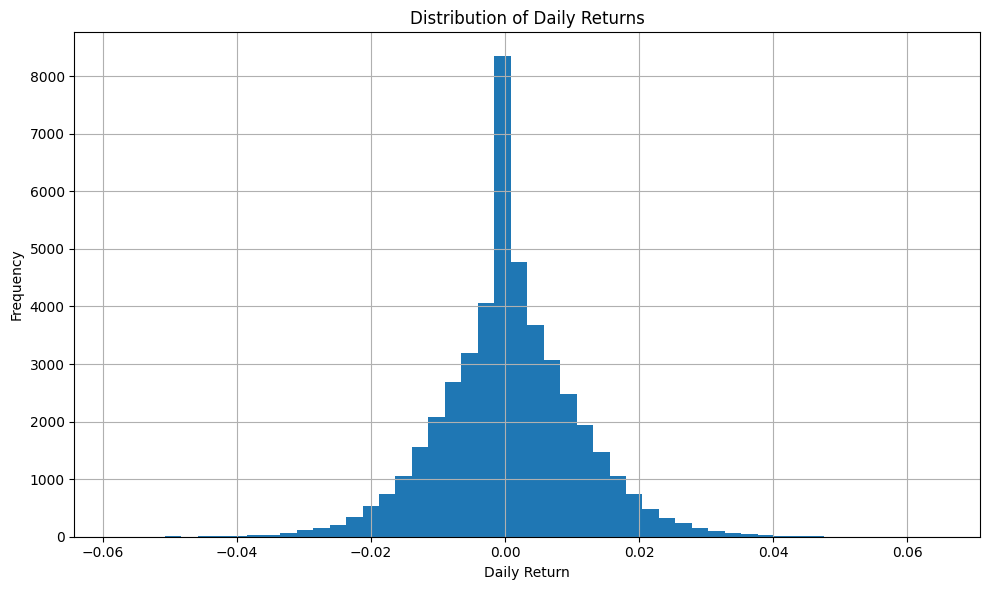

In [9]:
plt.figure(figsize=(10,6))
plt.hist(
    nav["daily_return"].dropna(),
    bins=50
)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.grid(True)
plt.tight_layout()
plt.savefig(
    r"E:\Project\reports\charts\daily_return_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

---

In [10]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(
    ["amfi_code", "date"]
)

In [11]:
cagr_list = []

In [18]:
for code in nav["amfi_code"].unique():
    fund_data = nav[nav["amfi_code"] == code].copy()
    fund_data = fund_data.sort_values("date")
    end_date = fund_data["date"].max()
    end_nav = fund_data.iloc[-1]["nav"]
    start_1 = end_date - pd.DateOffset(years=1)
    nav_1 = fund_data[fund_data["date"] >= start_1].iloc[0]["nav"]
    cagr_1 = ((end_nav / nav_1) ** (1/1) - 1) * 100
    start_3 = end_date - pd.DateOffset(years=3)
    nav_3 = fund_data[fund_data["date"] >= start_3].iloc[0]["nav"]
    cagr_3 = ((end_nav / nav_3) ** (1/3) - 1) * 100
    start_5 = end_date - pd.DateOffset(years=5)
    nav_5 = fund_data.iloc[0]["nav"]
    if len(fund_data[fund_data["date"] >= start_5]) > 0:
        nav_5 = fund_data[fund_data["date"] >= start_5].iloc[0]["nav"]
    cagr_5 = ((end_nav / nav_5) ** (1/5) - 1) * 100
    cagr_list.append([
        code,
        cagr_1,
        cagr_3,
        cagr_5
    ])

In [17]:
cagr = pd.DataFrame(
    cagr_list,
    columns=[
        "amfi_code",
        "cagr_1yr",
        "cagr_3yr",
        "cagr_5yr"
    ]
)

In [19]:
cagr_table = cagr_data[
    ["scheme_name", "start_nav", "end_nav", "cagr_5yr"]
]

cagr_table = cagr_table.sort_values(
    by="cagr_5yr",
    ascending=False
)

cagr_table.head(10)

NameError: name 'cagr_data' is not defined

In [15]:
cagr = pd.merge(
    cagr,
    fund[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code"
)

In [21]:
comparison_table = cagr[
    [
        "scheme_name",
        "cagr_1yr",
        "cagr_3yr",
        "cagr_5yr"
    ]
]

comparison_table = comparison_table.sort_values(
    by="cagr_5yr",
    ascending=False
)

comparison_table

,scheme_name,cagr_1yr,cagr_3yr,cagr_5yr
25,ICICI Pru Midcap Fund - Regular - Growth,29.604659,31.777537,28.376762
21,SBI Small Cap Fund - Regular Plan - Growth,82.776059,26.669922,28.033224
39,DSP Small Cap Fund - Regular - Growth,65.138719,27.000427,27.917430
36,Mirae Asset Tax Saver Fund - Regular - Growth,39.751761,29.178902,27.629860
34,Mirae Asset Large Cap Fund - Regular - Growth,20.360678,34.000916,26.799277
30,Kotak Flexicap Fund - Regular - Growth,26.657082,29.582770,26.742494
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,53.232396,32.442459,26.074068
38,DSP Midcap Fund - Regular - Growth,21.481222,26.869991,25.611807
16,Axis Midcap Fund - Regular - Growth,22.261065,35.111802,24.445309
19,SBI Bluechip Fund - Regular Plan - Growth,60.437341,30.456524,22.384873


In [22]:
comparison_table.to_csv(
    "E:/Project/data/processed/cagr_comparison.csv",
    index=False
)

---

In [23]:
rf = 0.065

In [24]:
sharpe = nav.groupby("amfi_code").agg(average_return=("daily_return","mean"),risk=("daily_return","std")).reset_index()

sharpe.head()

,amfi_code,average_return,risk
0,100016,0.000142,0.009164
1,100025,0.000170,0.002460
2,100033,0.001080,0.011929
3,101206,0.000852,0.009177
4,101207,0.000424,0.016251


In [25]:
sharpe["sharpe_ratio"] = ((sharpe["average_return"] - (rf/252)) / sharpe["risk"]) * np.sqrt(252)

sharpe.head()

,amfi_code,average_return,risk,sharpe_ratio
0,100016,0.000142,0.009164,-0.201517
1,100025,0.000170,0.002460,-0.567095
2,100033,0.001080,0.011929,1.093699
3,101206,0.000852,0.009177,1.027213
4,101207,0.000424,0.016251,0.162661


In [26]:
sharpe = pd.merge(sharpe,fund[["amfi_code","scheme_name"]],on="amfi_code")

In [27]:
sharpe = sharpe.sort_values(by="sharpe_ratio",ascending=False)
sharpe["rank"] = range(1, len(sharpe)+1)
sharpe.head(10)

,amfi_code,average_return,risk,sharpe_ratio,scheme_name,rank
34,148567,0.001074,0.008941,1.448291,Mirae Asset Large Cap Fund - Regular - Growth,1
30,120843,0.001082,0.010008,1.306744,Kotak Flexicap Fund - Regular - Growth,2
36,148569,0.001124,0.011134,1.234930,Mirae Asset Tax Saver Fund - Regular - Growth,3
19,119551,0.000917,0.008656,1.208267,SBI Bluechip Fund - Regular Plan - Growth,4
25,120505,0.001161,0.012152,1.180101,ICICI Pru Midcap Fund - Regular - Growth,5
38,149323,0.001055,0.011179,1.132122,DSP Midcap Fund - Regular - Growth,6
2,100033,0.001080,0.011929,1.093699,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,7
9,118632,0.000865,0.008913,1.081659,Nippon India Large Cap Fund - Regular - Growth,8
3,101206,0.000852,0.009177,1.027213,ABSL Frontline Equity Fund - Regular - Growth,9
24,120504,0.000843,0.009048,1.026524,ICICI Pru Bluechip Fund - Direct - Growth,10


In [28]:
sharpe.to_csv("E:/project/data/processed/sharpe_ratio.csv",index=False)

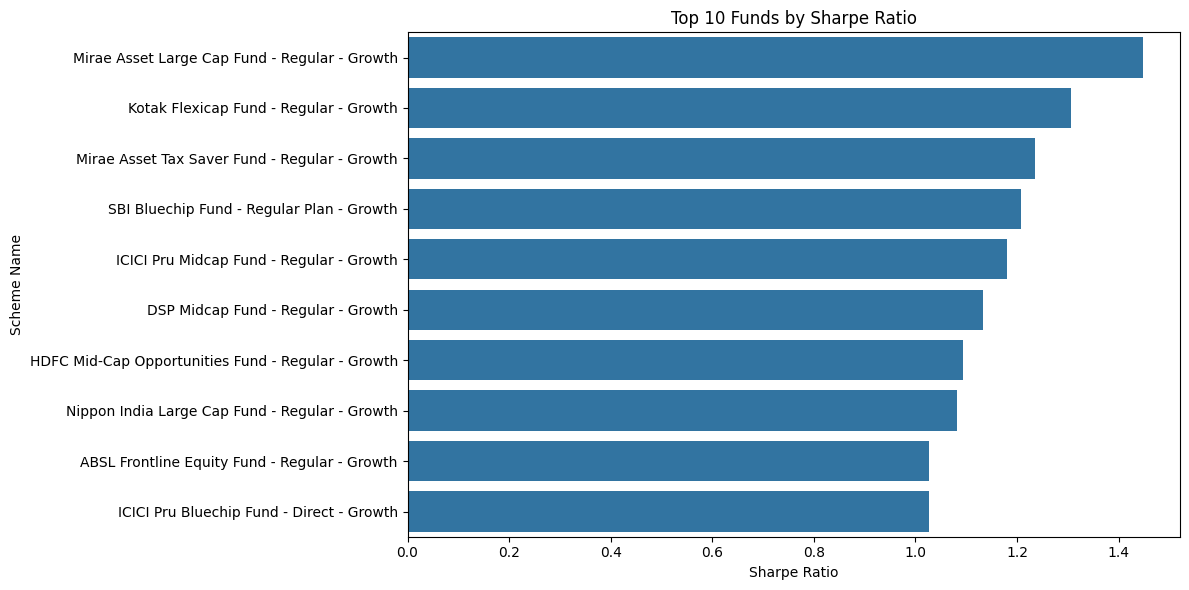

In [29]:
top10 = sharpe.head(10)
plt.figure(figsize=(12,6))
sns.barplot(data=top10,x="sharpe_ratio",y="scheme_name")

plt.title("Top 10 Funds by Sharpe Ratio")
plt.xlabel("Sharpe Ratio")
plt.ylabel("Scheme Name")
plt.tight_layout()
plt.savefig( r"E:\Project\reports\charts\sharpe_ratio.png",dpi=300,bbox_inches="tight")

plt.show()

---

In [30]:
rf = 0.065

In [31]:
sortino_list = []

In [32]:
for code in nav["amfi_code"].unique():
    fund_data = nav[nav["amfi_code"] == code]
    average_return = fund_data["daily_return"].mean()
    downside_returns = fund_data[fund_data["daily_return"] < 0 ]["daily_return"]
    downside_std = downside_returns.std()
    sortino_ratio = ((average_return - (rf / 252)) / downside_std) * np.sqrt(252)
    sortino_list.append([code, sortino_ratio])

In [33]:
sortino = pd.DataFrame( sortino_list,columns=[
        "amfi_code",
        "sortino_ratio"])

sortino.head()

,amfi_code,sortino_ratio
0,100016,-0.351047
1,100025,-0.941821
2,100033,1.829134
3,101206,1.799563
4,101207,0.276644


In [34]:
sortino = pd.merge(sortino,fund[["amfi_code", "scheme_name"]],on="amfi_code")

sortino.head()

,amfi_code,sortino_ratio,scheme_name
0,100016,-0.351047,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,-0.941821,HDFC Short Term Debt Fund - Regular - Growth
2,100033,1.829134,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,1.799563,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.276644,ABSL Small Cap Fund - Regular - Growth


In [35]:
sortino = sortino.sort_values(by="sortino_ratio",ascending=False)
sortino["rank"] = range(1,len(sortino)+1)

sortino.head(10)

,amfi_code,sortino_ratio,scheme_name,rank
34,148567,2.385644,Mirae Asset Large Cap Fund - Regular - Growth,1
30,120843,2.364320,Kotak Flexicap Fund - Regular - Growth,2
36,148569,2.146914,Mirae Asset Tax Saver Fund - Regular - Growth,3
19,119551,2.140267,SBI Bluechip Fund - Regular Plan - Growth,4
25,120505,2.029353,ICICI Pru Midcap Fund - Regular - Growth,5
38,149323,1.875101,DSP Midcap Fund - Regular - Growth,6
9,118632,1.850133,Nippon India Large Cap Fund - Regular - Growth,7
2,100033,1.829134,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,8
24,120504,1.805294,ICICI Pru Bluechip Fund - Direct - Growth,9
3,101206,1.799563,ABSL Frontline Equity Fund - Regular - Growth,10


In [36]:
sortino.to_csv("E:/project/data/processed/sortino_ratio.csv",index=False)

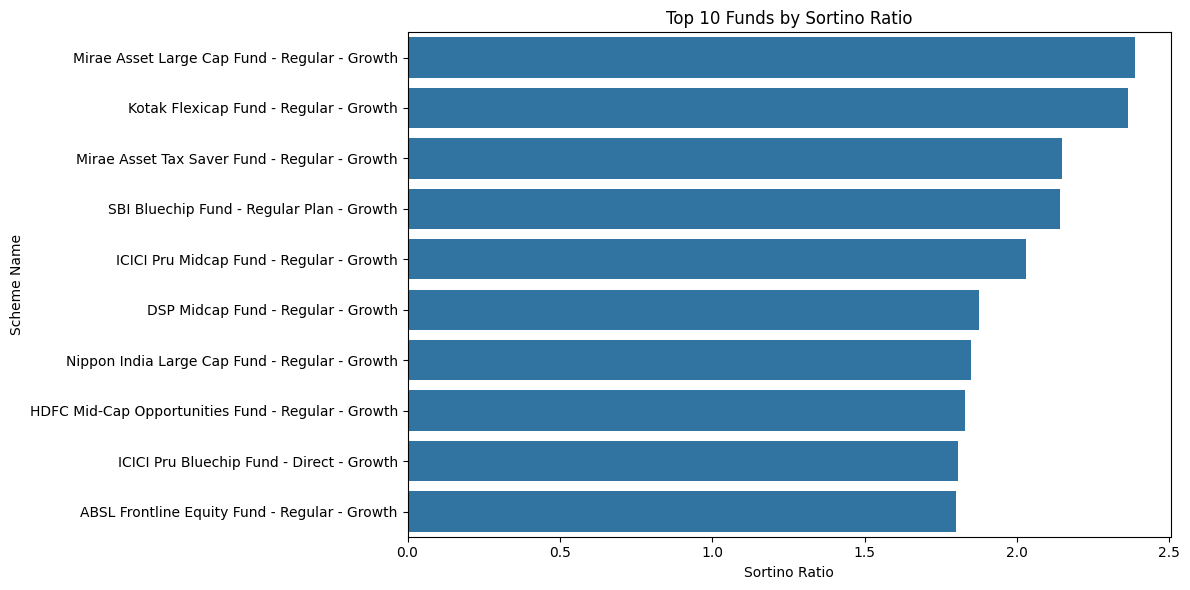

In [37]:
top10 = sortino.head(10)
plt.figure(figsize=(12,6))
sns.barplot(data=top10,x="sortino_ratio",y="scheme_name")
plt.title("Top 10 Funds by Sortino Ratio")
plt.xlabel("Sortino Ratio")
plt.ylabel("Scheme Name")
plt.tight_layout()
plt.savefig(r"E:\Project\reports\charts\sortino_ratio.png",dpi=300,bbox_inches="tight")

plt.show()

---

In [40]:
nifty100 = benchmark[benchmark["index_name"] == "NIFTY100"].copy()

nifty100.head()

,date,index_name,close_value
1150,2022-01-03,NIFTY100,17778.24
1151,2022-01-04,NIFTY100,17537.52
1152,2022-01-05,NIFTY100,17607.73
1153,2022-01-06,NIFTY100,17556.05
1154,2022-01-07,NIFTY100,17664.02


In [41]:
nifty100["date"] = pd.to_datetime(nifty100["date"])

nifty100 = nifty100.sort_values("date")

In [42]:
nifty100["benchmark_return"] = nifty100["close_value"].pct_change()

nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [43]:
alpha_beta = []

In [45]:
for code in nav["amfi_code"].unique():

    fund_data = nav[
        nav["amfi_code"] == code
    ].copy()

    merged = pd.merge(
        fund_data,
        nifty100[["date","benchmark_return"]],
        on="date"
    )

    merged = merged.dropna()

    slope, intercept, r_value, p_value, std_err = linregress(
        merged["benchmark_return"],
        merged["daily_return"]
    )

    alpha = intercept * 252

    beta = slope

    alpha_beta.append(
        [code, alpha, beta]
    )

In [46]:
alpha_beta = pd.DataFrame(alpha_beta,columns=[
        "amfi_code",
        "alpha",
        "beta"])

alpha_beta.head()

,amfi_code,alpha,beta
0,100016,0.037476,-0.058268
1,100025,0.042818,0.001158
2,100033,0.271954,0.005104
3,101206,0.213998,0.021086
4,101207,0.108971,-0.065289


In [47]:
alpha_beta = pd.merge(alpha_beta,fund[["amfi_code","scheme_name"]],on="amfi_code")
alpha_beta.head()

,amfi_code,alpha,beta,scheme_name
0,100016,0.037476,-0.058268,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,0.042818,0.001158,HDFC Short Term Debt Fund - Regular - Growth
2,100033,0.271954,0.005104,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,0.213998,0.021086,ABSL Frontline Equity Fund - Regular - Growth
4,101207,0.108971,-0.065289,ABSL Small Cap Fund - Regular - Growth


In [52]:
alpha_beta = pd.merge(
    alpha_beta,
    fund[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

alpha_beta.head()

,amfi_code,alpha,beta,scheme_name_x,scheme_name_y,scheme_name
0,119598,0.303370,-0.023196,SBI Small Cap Fund - Regular Plan - Growth,SBI Small Cap Fund - Regular Plan - Growth,SBI Small Cap Fund - Regular Plan - Growth
1,149324,0.300579,0.011455,DSP Small Cap Fund - Regular - Growth,DSP Small Cap Fund - Regular - Growth,DSP Small Cap Fund - Regular - Growth
2,120505,0.292636,0.000549,ICICI Pru Midcap Fund - Regular - Growth,ICICI Pru Midcap Fund - Regular - Growth,ICICI Pru Midcap Fund - Regular - Growth
3,148569,0.282704,0.018134,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset Tax Saver Fund - Regular - Growth
4,120843,0.273305,-0.022830,Kotak Flexicap Fund - Regular - Growth,Kotak Flexicap Fund - Regular - Growth,Kotak Flexicap Fund - Regular - Growth


In [53]:
alpha_beta.to_csv(
    "E:/project/data/processed/alpha_beta.csv",
    index=False
)

In [54]:
alpha_beta = alpha_beta.sort_values(by="alpha",ascending=False)

alpha_beta.head(10)

,amfi_code,alpha,beta,scheme_name_x,scheme_name_y,scheme_name
0,119598,0.303370,-0.023196,SBI Small Cap Fund - Regular Plan - Growth,SBI Small Cap Fund - Regular Plan - Growth,SBI Small Cap Fund - Regular Plan - Growth
1,149324,0.300579,0.011455,DSP Small Cap Fund - Regular - Growth,DSP Small Cap Fund - Regular - Growth,DSP Small Cap Fund - Regular - Growth
2,120505,0.292636,0.000549,ICICI Pru Midcap Fund - Regular - Growth,ICICI Pru Midcap Fund - Regular - Growth,ICICI Pru Midcap Fund - Regular - Growth
3,148569,0.282704,0.018134,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset Tax Saver Fund - Regular - Growth,Mirae Asset Tax Saver Fund - Regular - Growth
4,120843,0.273305,-0.022830,Kotak Flexicap Fund - Regular - Growth,Kotak Flexicap Fund - Regular - Growth,Kotak Flexicap Fund - Regular - Growth
5,100033,0.271954,0.005104,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
6,148567,0.269838,0.023684,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset Large Cap Fund - Regular - Growth
7,149323,0.265986,-0.002523,DSP Midcap Fund - Regular - Growth,DSP Midcap Fund - Regular - Growth,DSP Midcap Fund - Regular - Growth
8,119094,0.260767,-0.066265,Axis Midcap Fund - Regular - Growth,Axis Midcap Fund - Regular - Growth,Axis Midcap Fund - Regular - Growth
9,119551,0.232010,-0.031751,SBI Bluechip Fund - Regular Plan - Growth,SBI Bluechip Fund - Regular Plan - Growth,SBI Bluechip Fund - Regular Plan - Growth


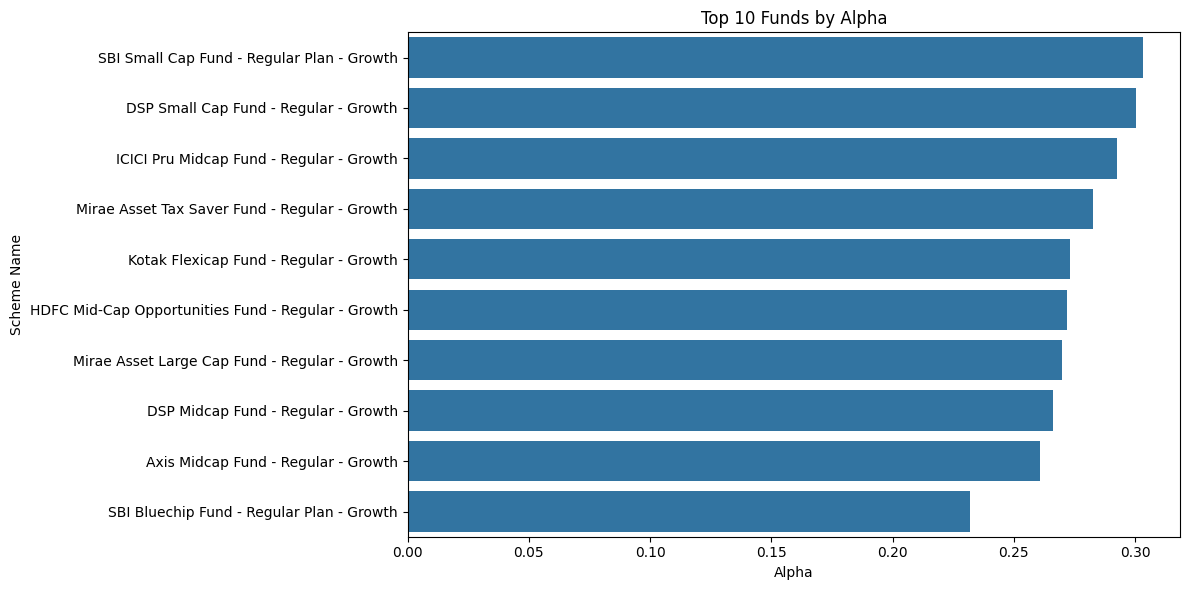

In [55]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=alpha_beta.head(10),
    x="alpha",
    y="scheme_name"
)

plt.title("Top 10 Funds by Alpha")
plt.xlabel("Alpha")
plt.ylabel("Scheme Name")
plt.tight_layout()
plt.savefig(
    r"E:\Project\reports\charts\alpha_chart.png",
    dpi=300
)

plt.show()

---

In [57]:
drawdown_list = []

In [65]:
drawdown_list = []

for code in nav["amfi_code"].unique():
    fund_data = nav[nav["amfi_code"] == code].copy()
    fund_data = fund_data.sort_values("date")
    fund_data["running_max"] = fund_data["nav"].cummax()
    fund_data["drawdown"] = (fund_data["nav"] / fund_data["running_max"]) - 1

    max_drawdown = fund_data["drawdown"].min()
    
    trough_date = fund_data.loc[fund_data["drawdown"].idxmin(),"date"]
    peak_data = fund_data[fund_data["date"] <= trough_date]
    peak_date = peak_data.loc[peak_data["nav"].idxmax(),"date"]
    drawdown_list.append([
        code,
        peak_date,
        trough_date,
        max_drawdown
    ])

In [66]:
drawdown = pd.DataFrame(
    drawdown_list,
    columns=[
        "amfi_code",
        "peak_date",
        "trough_date",
        "max_drawdown"
    ]
)

drawdown.head()

,amfi_code,peak_date,trough_date,max_drawdown
0,100016,2022-03-30,2022-09-15,-0.247344
1,100025,2023-05-23,2023-07-28,-0.043083
2,100033,2022-03-11,2022-05-12,-0.162172
3,101206,2023-04-24,2023-07-05,-0.112916
4,101207,2024-11-21,2026-05-11,-0.354469


In [67]:
drawdown = pd.merge(
    drawdown,
    fund[
        ["amfi_code","scheme_name"]
    ],
    on="amfi_code"
)

drawdown.head()

,amfi_code,peak_date,trough_date,max_drawdown,scheme_name
0,100016,2022-03-30,2022-09-15,-0.247344,HDFC Top 100 Fund - Regular Plan - Growth
1,100025,2023-05-23,2023-07-28,-0.043083,HDFC Short Term Debt Fund - Regular - Growth
2,100033,2022-03-11,2022-05-12,-0.162172,HDFC Mid-Cap Opportunities Fund - Regular - Gr...
3,101206,2023-04-24,2023-07-05,-0.112916,ABSL Frontline Equity Fund - Regular - Growth
4,101207,2024-11-21,2026-05-11,-0.354469,ABSL Small Cap Fund - Regular - Growth


In [68]:
drawdown = drawdown.sort_values(
    by="max_drawdown"
)

drawdown.head(10)

,amfi_code,peak_date,trough_date,max_drawdown,scheme_name
22,119599,2023-01-17,2025-10-28,-0.525742,SBI Small Cap Fund - Direct Plan - Growth
17,119095,2025-05-22,2026-05-11,-0.516778,Axis Small Cap Fund - Regular - Growth
4,101207,2024-11-21,2026-05-11,-0.354469,ABSL Small Cap Fund - Regular - Growth
39,149324,2024-05-03,2025-01-03,-0.311719,DSP Small Cap Fund - Regular - Growth
21,119598,2024-08-28,2025-05-14,-0.287060,SBI Small Cap Fund - Regular Plan - Growth
7,102886,2025-01-07,2026-04-27,-0.280011,UTI Mid Cap Fund - Regular - Growth
0,100016,2022-03-30,2022-09-15,-0.247344,HDFC Top 100 Fund - Regular Plan - Growth
29,120842,2023-11-09,2024-10-17,-0.240035,Kotak Emerging Equity Fund - Regular - Growth
11,118634,2025-04-09,2026-02-20,-0.233449,Nippon India Small Cap Fund - Regular - Growth
15,119093,2022-02-24,2023-05-22,-0.217514,Axis Bluechip Fund - Direct - Growth


In [69]:
drawdown.to_csv(
    "E:/project/data/processed/max_drawdown.csv",
    index=False
)

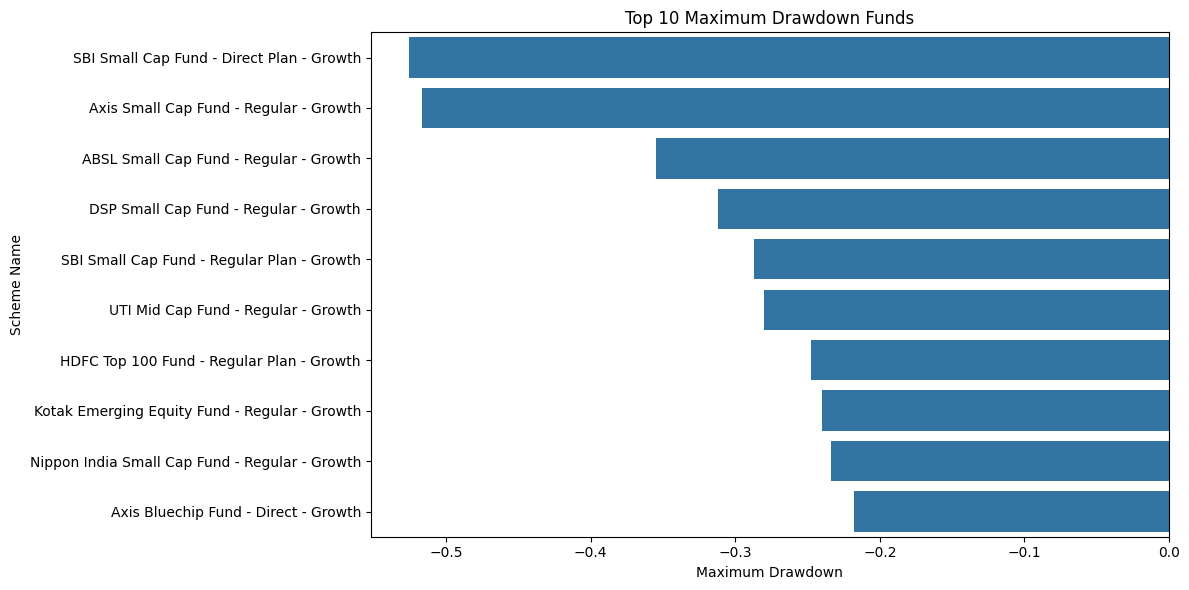

In [70]:
plt.figure(figsize=(12,6))
sns.barplot(
    data=drawdown.head(10),
    x="max_drawdown",
    y="scheme_name")
plt.title("Top 10 Maximum Drawdown Funds")
plt.xlabel("Maximum Drawdown")
plt.ylabel("Scheme Name")
plt.tight_layout()
plt.savefig(
    r"E:\Project\reports\charts\max_drawdown.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

---

In [71]:
score = fund.copy()

score.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [83]:
score = score.merge(performance[["amfi_code","return_3yr_pct"]],on="amfi_code",how="left")

In [73]:
score = score.merge(sharpe[["amfi_code","sharpe_ratio"]],on="amfi_code")

In [88]:
score = score.merge( alpha_beta[["amfi_code","alpha"]],on="amfi_code")

MergeError: Passing 'suffixes' which cause duplicate columns {'alpha_y', 'alpha_x'} is not allowed.

In [85]:
score = score.merge(drawdown[["amfi_code","max_drawdown"]],on="amfi_code")

In [86]:
score["return_rank"] = score["return_3yr_pct"].rank(ascending=False)

score["sharpe_rank"] = score["sharpe_ratio"].rank(ascending=False)

score["alpha_rank"] = score["alpha"].rank(ascending=False)

score["expense_rank"] = score["expense_ratio_pct"].rank(ascending=True)

score["drawdown_rank"] = score["max_drawdown"].rank(ascending=False)

KeyError: 'alpha'